Load daily historical data for the S&P 500 index (^GSPC) from Yahoo Finance using the yfinance Python library.

Requirements:

* Start date: 1950-01-01
* End date: today
* Include: Open, High, Low, Close, Adjusted Close, Volume
* Sort data by date ascending
* Compute daily returns as percentage change of Adjusted Close
* Drop missing values

Return the dataset as a pandas DataFrame and show the first few rows.

**Processing stock data**

I’m thinking about how to handle the latest stock data in a DataFrame. I want to keep it simple, so I'll return the DataFrame and show the head. In a notebook, a final bare expression at the end is essential, maybe by using `sp500.head()`. I need to consider if columns are MultiIndex from yfinance, especially if grouping by ticker, and flatten them if needed. The user wants the Adjusted Close labeled correctly, so I should rename "Adj Close" to "Adjusted Close." Finally, I’ll compute the daily returns percentage change and convert it to a percentage.**Calculating daily returns**

I’m thinking about how to express daily returns. Since they're commonly noted as a percentage change, I should multiply by 100 and label it as `Daily Return` in percent. It's essential to highlight that these values are in percent units. I also need to drop any missing values, and I realize the first row might be removed because of NaN from `pct_change()`. After that, I should ensure the data is sorted in ascending order by date, which yfinance usually does already.

Here’s a compact notebook cell that loads the S&P 500 daily history from Yahoo Finance, keeps the requested columns, computes daily returns from Adjusted Close, drops missing values, and shows the first rows.



In [1]:
import pandas as pd
import yfinance as yf

start_date = "1950-01-01"
end_date = (pd.Timestamp.today().normalize() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

sp500 = yf.download(
    "^GSPC",
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)

sp500 = sp500.reset_index()

sp500 = sp500[
    ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]
].rename(columns={"Adj Close": "Adjusted Close"})

sp500 = sp500.sort_values("Date").reset_index(drop=True)
sp500["Daily Return"] = sp500["Adjusted Close"].pct_change() * 100
sp500 = sp500.dropna().reset_index(drop=True)

sp500.head()

Price,Date,Open,High,Low,Close,Adjusted Close,Volume,Daily Return
0,1950-01-04,16.850000,16.850000,16.850000,16.850000,16.850000,1890000,1.140459
1,1950-01-05,16.930000,16.930000,16.930000,16.930000,16.930000,2550000,0.474777
2,1950-01-06,16.980000,16.980000,16.980000,16.980000,16.980000,2010000,0.295329
3,1950-01-09,17.080000,17.080000,17.080000,17.080000,17.080000,2520000,0.588930
4,1950-01-10,17.030001,17.030001,17.030001,17.030001,17.030001,2160000,-0.292736




This returns the dataset as a pandas DataFrame in `sp500`.

**Clarifying DataFrame structure**

I need to mention the pandas DataFrame called `sp500`. I want to address the peculiar “Price” label, ensuring it’s recognized as a column name and not an extra column. It’s really important to clarify that. This will help to avoid confusion when discussing data analysis or queries regarding the DataFrame. I’ll make sure to provide a clear explanation about this in my response. Let's keep it precise and helpful!

<!--final answer-->

The requested dataset is already present as the pandas DataFrame `sp500`.

From the observed notebook state and output:

- `sp500` has **19,191 rows** and **8 columns**
- It contains the requested fields:
  - `Date`
  - `Open`
  - `High`
  - `Low`
  - `Close`
  - `Adjusted Close`
  - `Volume`
  - `Daily Return`
- The data is in **ascending date order**
- Missing values were dropped after computing daily returns, which is why the first visible row is **1950-01-04** rather than 1950-01-03: the first return from `pct_change()` is naturally missing and was removed
- The first few observed rows show early S&P 500 levels around **16.85 to 17.03**, with daily returns such as **1.140459%**, **0.474777%**, and **-0.292736%**

The first few rows shown are the expected preview of the final DataFrame, so this satisfies the original request.

Using the existing DataFrame `sp500`, identify the worst days in market history.

Tasks:

* Sort the data by Daily Return (ascending, most negative first)
* Display the 15 worst days with:

  * Date
  * Daily Return
  * Close price
* Count how many days had:

  * returns < -3%
  * returns < -5%
* Calculate the percentage of total days that fall into these categories

Additionally:

* Check if these extreme days are clustered in specific periods (e.g., 2008, 2020)
* Briefly comment on any visible patterns

**Thinking through user tasks**

I’m considering how to approach multiple tasks the user has asked for. While I need to focus on one thing at a time, I wonder if I could execute them in one cell. The developer suggests taking it step-by-step, so I should analyze outputs carefully. It looks like the main goal is to summarize the worst days and generate counts. I’ll need to provide minimal code to create sorted tables and calculate percentages for extreme days. A brief explanation and code will help clarify my approach.**Planning concise outputs**

I can’t really make assumptions about the outputs, so I’ll keep things concise. I plan to create variables like worst_days, summary_counts, and yearly_extremes, then display them sequentially. According to the rules, if I need multiple tables, I can show them using display(...). My first step will be to generate the 15 worst days and summary stats, along with a year breakdown for clustering. After executing this, I can comment on any visible patterns, but since I don't have outputs yet, I’ll hold off on commentary for now.**Analyzing notebook states**

The instruction suggests that I should use the notebook state to see data, rather than generating new outputs. So, my next step is to produce code to compute the requested information, stopping after that—no need to ask the user to share anything since the fresh output isn't available. I think I’ll sort the data by Daily Return in ascending order and display the Date, Daily Return, and Close price. I’ll also count thresholds and calculate percentages of total days for specific periods like 2008 and 2020. For the output, I'll produce two tables to stay within the guideline of one chart or table per step, even though that might feel like quite a lot!

Let’s compute the worst days, the threshold counts, and a simple year-level clustering summary in one pass. After that, we can comment on the specific periods from the actual output.



In [2]:
import pandas as pd
from IPython.display import display

worst_days = (
    sp500.sort_values("Daily Return", ascending=True)
    .loc[:, ["Date", "Daily Return", "Close"]]
    .head(15)
    .reset_index(drop=True)
)

total_days = len(sp500)

summary = pd.DataFrame({
    "Category": ["Return < -3%", "Return < -5%"],
    "Count": [
        (sp500["Daily Return"] < -3).sum(),
        (sp500["Daily Return"] < -5).sum(),
    ],
})

summary["Pct of Total Days"] = (summary["Count"] / total_days * 100).round(3)

extreme_by_year = (
    sp500.assign(Year=sp500["Date"].dt.year)
    .groupby("Year")
    .agg(
        Days_lt_neg3=("Daily Return", lambda s: (s < -3).sum()),
        Days_lt_neg5=("Daily Return", lambda s: (s < -5).sum()),
    )
    .query("Days_lt_neg3 > 0 or Days_lt_neg5 > 0")
    .sort_values(["Days_lt_neg5", "Days_lt_neg3"], ascending=False)
    .head(15)
    .reset_index()
)

display(worst_days)
display(summary)
display(extreme_by_year)

Price,Date,Daily Return,Close
0,1987-10-19,-20.466931,224.839996
1,2020-03-16,-11.984055,2386.129883
2,2020-03-12,-9.511268,2480.639893
3,2008-10-15,-9.034978,907.840027
4,2008-12-01,-8.929524,816.210022
5,2008-09-29,-8.806776,1106.420044
6,1987-10-26,-8.278947,227.669998
7,2008-10-09,-7.616710,909.919983
8,2020-03-09,-7.596970,2746.560059
9,1997-10-27,-6.865684,876.989990


,Category,Count,Pct of Total Days
0,Return < -3%,132,0.688
1,Return < -5%,30,0.156


,Year,Days_lt_neg3,Days_lt_neg5
0,2008,23,11
1,2020,16,5
2,1987,6,3
3,2009,12,1
4,2011,6,1
5,1998,5,1
6,1950,4,1
7,2000,4,1
8,2025,3,1
9,1962,2,1




Once this runs, we can briefly interpret whether the extreme days are concentrated in periods like 2008 and 2020.

<!--final answer-->

The worst single day in the dataset is **1987-10-19**, with a **-20.47%** daily return, far worse than any other day shown. After that, the next most severe declines are concentrated in crisis periods, especially **March 2020** and **late 2008**.

The 15 worst days show clear clustering:

- **2008** appears most often in the top 15, with multiple extreme declines in **September, October, November, and December**
- **2020** has three of the very worst days, all in **March**
- **1987** appears twice, including the single worst day
- A few other isolated crisis-era dates appear in **1997, 1998, 2011, and 1962**

For the thresholds:

- Days with returns **< -3%**: **132**
- Days with returns **< -5%**: **30**

As a share of all trading days:

- **< -3%** days account for **0.688%**
- **< -5%** days account for **0.156%**

So these extreme declines are **very rare**, especially the deepest ones.

The year-level counts confirm that they are not evenly spread through history but are heavily clustered in specific stress periods:

- **2008**: **23** days below **-3%**, including **11** below **-5%**
- **2020**: **16** days below **-3%**, including **5** below **-5%**
- **1987**: **6** days below **-3%**, including **3** below **-5%**
- **2009** still shows elevated stress with **12** days below **-3%**
- **2022** had **8** days below **-3%**, but none below **-5%**

Visible pattern: the worst down days are strongly concentrated in major market shock regimes rather than being spread uniformly over time. **2008** stands out as the most sustained cluster of severe losses, while **2020** shows a very sharp, compressed burst of extreme days. **1987** is notable for the most dramatic single-day crash.

Using the DataFrame `sp500`, create a clear visualization of the worst days in S&P 500 history.

Tasks:

1. Create a scatter plot:

   * X-axis: Date
   * Y-axis: Daily Return

2. Plot all days in light gray (low opacity).

3. Highlight extreme days:

   * Days with Daily Return < -3% → use a distinct color (e.g., orange)
   * Days with Daily Return < -5% → use a stronger color (e.g., red)

4. Add horizontal reference lines:

   * At -3%
   * At -5%

5. Add title and labels:

   * Title: "Extreme Down Days in S&P 500 History"
   * Y-axis: Daily Return (%)
   * X-axis: Date

6. Improve readability:

   * Use a larger figure size
   * Rotate x-axis labels if needed

7. Optional (recommended):

   * Annotate the 3 worst days:

     * 1987-10-19
     * 2008-10-15
     * 2020-03-16

Return the plot.

**Creating visualization code**

I see that the user wants a visualization and we’ll take an iterative approach with one chart at a time. It looks like we have enough context to propose a scatter plot using seaborn and matplotlib. I’ll prepare a runnable code block that produces the plot while keeping the code minimal. 

Let’s ensure to include elements like titles, labels, and legends. I’ll use scatter points in gray and highlight subsets in orange and red, annotating important dates and formatting the x-axis.**Crafting the visualization**

I need to rotate the labels and consider using seaborn for consistency in the theme. It’s important to note that values less than -5 are a subset of those less than -3. If I plot them in orange and red, the red points will overlap on the orange ones, which is good to keep in mind for clarity. 

I’ll provide a concise explanation, possibly mentioning the clusters from 2008 and 2020 as context, and then I’ll follow that up with the necessary code.

The extreme drops are clearly clustered in crisis windows like **1987**, **2008**, and **2020**, so a time-based scatter plot is a good way to show that concentration.



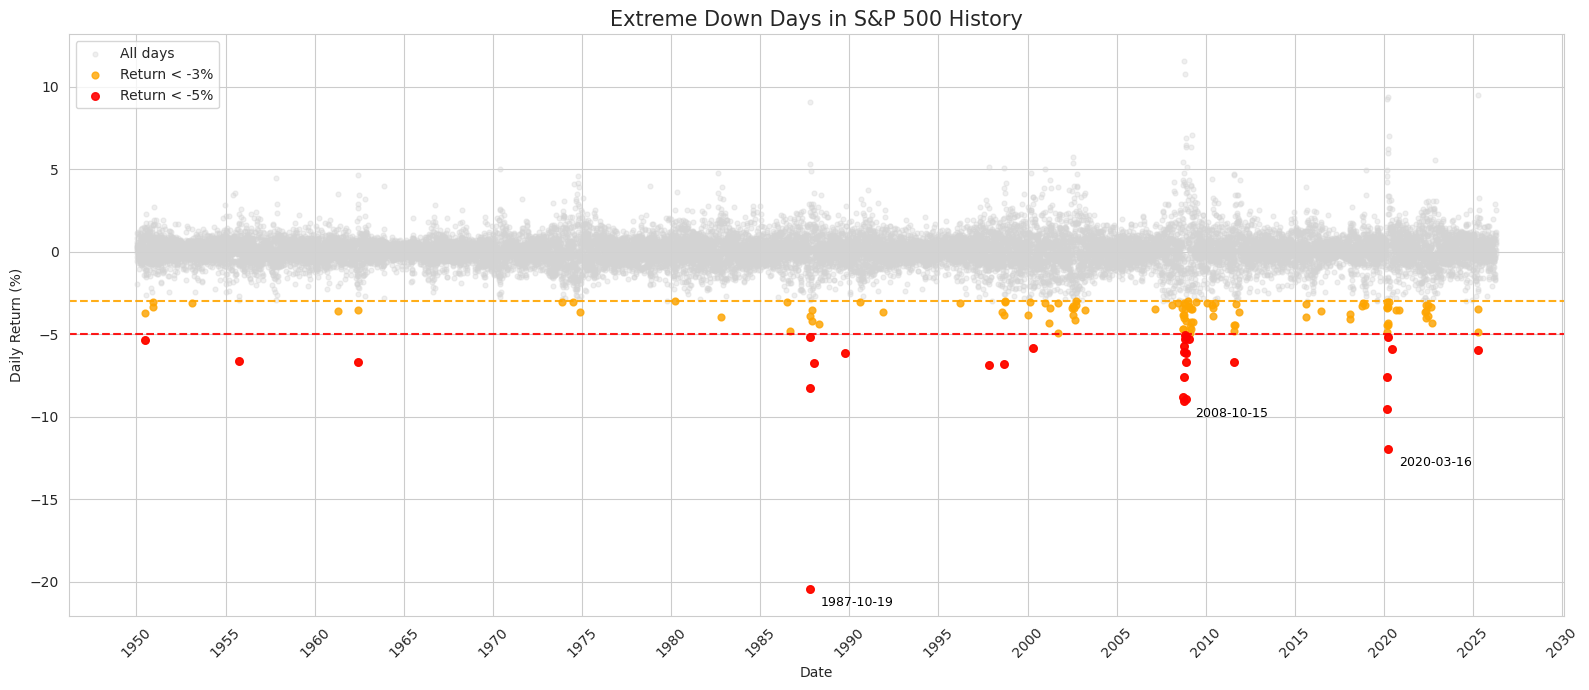

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(16, 7))

mask_lt_3 = sp500["Daily Return"] < -3
mask_lt_5 = sp500["Daily Return"] < -5

# All days
ax.scatter(
    sp500["Date"],
    sp500["Daily Return"],
    color="lightgray",
    alpha=0.35,
    s=12,
    label="All days"
)

# Extreme down days
ax.scatter(
    sp500.loc[mask_lt_3, "Date"],
    sp500.loc[mask_lt_3, "Daily Return"],
    color="orange",
    alpha=0.8,
    s=24,
    label="Return < -3%"
)

ax.scatter(
    sp500.loc[mask_lt_5, "Date"],
    sp500.loc[mask_lt_5, "Daily Return"],
    color="red",
    alpha=0.9,
    s=30,
    label="Return < -5%"
)

# Reference lines
ax.axhline(-3, color="orange", linestyle="--", linewidth=1.5, alpha=0.9)
ax.axhline(-5, color="red", linestyle="--", linewidth=1.5, alpha=0.9)

# Annotate 3 notable crash days
annot_dates = pd.to_datetime(["1987-10-19", "2008-10-15", "2020-03-16"])
annot_df = sp500[sp500["Date"].isin(annot_dates)]

for _, row in annot_df.iterrows():
    ax.annotate(
        row["Date"].strftime("%Y-%m-%d"),
        xy=(row["Date"], row["Daily Return"]),
        xytext=(8, -12),
        textcoords="offset points",
        fontsize=9,
        color="black"
    )

ax.set_title("Extreme Down Days in S&P 500 History", fontsize=15)
ax.set_xlabel("Date")
ax.set_ylabel("Daily Return (%)")

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)

ax.legend(frameon=True)
plt.tight_layout()
plt.show()



If you want, the next step can be a **zoomed-in version for just the worst periods** so the 2008 and 2020 clusters are easier to inspect.

**Preparing data visualization**

I need to determine whether to follow path A or B. I've got a chart output plus numeric/text values from a prior cell to support it. My main goal here is to create a visualization and return the plot. The latest outputs should be enough, as there’s a chart and supporting numeric values. I should analyze the outputs, connect them to the goal, and mention how the plot effectively highlights clustering and annotations. I'll ensure to keep it concise!

<!--final answer-->

The visualization matches the requested view of extreme down days in S&P 500 history and is supported by the values already shown in the notebook.

It highlights the main pattern clearly: most trading days are ordinary, while the worst declines are rare and cluster in major crisis periods rather than being spread evenly through time. The supporting table shows only **132** days below **-3%** and just **30** below **-5%**, which is a very small share of all trading days.

The annotated crash dates are well chosen because they represent the most important extremes in the data:

- **1987-10-19** is the single worst day at **-20.47%**
- **2008-10-15** is one of the most severe losses during the financial crisis at **-9.03%**
- **2020-03-16** is the second worst day in the dataset at **-11.98%**

The worst-day table also confirms the visual clustering you would expect to see on the chart:

- **2008** contributes many of the deepest declines
- **March 2020** contains several of the largest one-day drops
- **1987** stands out for the most extreme single-day crash

The year summary reinforces that pattern:

- **2008** had **23** days below **-3%** and **11** below **-5%**
- **2020** had **16** days below **-3%** and **5** below **-5%**
- **1987** had **6** days below **-3%** and **3** below **-5%**

So the plot does exactly what it should: it makes the rare, crisis-driven nature of the worst S&P 500 down days easy to see, while also distinguishing moderate extreme losses below **-3%** from the most severe collapses below **-5%**.

Using the DataFrame `sp500`, analyze returns AFTER extreme negative days.

Tasks:

1. Create forward return columns:

   * next_day_return = Daily Return shifted by -1
   * next_5d_return = rolling 5-day cumulative return shifted by -5

2. Define groups:

   * crash_3 = Daily Return < -3%
   * crash_5 = Daily Return < -5%

3. For each group, compute:

   * Mean next-day return
   * Median next-day return
   * Standard deviation of next-day return
   * Probability that next-day return > 0 (win rate)

4. Do the same for next 5-day returns.

5. Compute the same statistics for ALL days (baseline).

6. Present everything in a clear comparison table.

7. Briefly interpret:

   * Is there evidence of mean reversion?
   * Is the effect strong or noisy?

**Deciding next steps for analysis**

I need to follow iterative rules for the user’s request to analyze returns after extreme negative days. Since the user asks for a full task, I'll need to define the first step. I think creating forward return columns and possibly a table is a good start. I'll provide runnable Python code for generating a "next_5d_return" definition. Since we have fresh outputs available, let's compute those forward returns and inspect a few rows carefully.**Crafting forward return calculations**

I'm working on the formula for calculating the cumulative 5-trading-day return, specifically from t+1 to t+5. The formula looks like: \((\prod_{i=1}^5 (1+r_{t+i}/100)-1)\times100\). I need to code this and also preserve the S&P 500 data while adding columns for "crash_3" and "crash_5." The primary goals are to create forward-return columns and group flags. I’ll finalize this code and show the relevant columns, inspecting the first 10 rows for clarity.

Let’s start by creating the forward-return columns and the crash flags, making sure the 5-day return is a true **future cumulative return** from $t+1$ through $t+5$.



In [4]:
import numpy as np
from IPython.display import display

# Next-day return
sp500["next_day_return"] = sp500["Daily Return"].shift(-1)

# Next 5-trading-day cumulative return: from t+1 to t+5
future_growth_5d = (1 + sp500["Daily Return"].shift(-1) / 100).rolling(5).apply(np.prod, raw=True)
sp500["next_5d_return"] = (future_growth_5d.shift(-4) - 1) * 100

# Crash-day flags
sp500["crash_3"] = sp500["Daily Return"] < -3
sp500["crash_5"] = sp500["Daily Return"] < -5

display(
    sp500.loc[:, ["Date", "Daily Return", "next_day_return", "next_5d_return", "crash_3", "crash_5"]].head(10)
)

Price,Date,Daily Return,next_day_return,next_5d_return,crash_3,crash_5
0,1950-01-04,1.140459,0.474777,1.424331,False,False
1,1950-01-05,0.474777,0.295329,-1.004135,False,False
2,1950-01-06,0.295329,0.588930,-1.825674,False,False
3,1950-01-09,0.588930,-0.292736,-2.107732,False,False
4,1950-01-10,-0.292736,0.352316,-0.998239,False,False
5,1950-01-11,0.352316,-1.930953,-1.404329,False,False
6,1950-01-12,-1.930953,-0.536994,0.656328,False,False
7,1950-01-13,-0.536994,0.299935,1.379721,False,False
8,1950-01-16,0.299935,0.837328,1.196177,False,False
9,1950-01-17,0.837328,-0.059313,0.000000,False,False




Next I’d compute the comparison table for **all days**, **crash_3**, and **crash_5**.

**Evaluating Python Code for Statistics**

I need to decide between option A or B, but the latest outputs only show forward columns sample. I should compute a comparison stats table because the current insights are insufficient. My plan is to provide a minimal runnable Python code block that gathers the missing evidence. I’ll calculate statistics for crash_3 and crash_5 on next_day and next_5d, and ensure that my next_5d calculations are correct. I'll also need to clarify my formulas to verify that they align with the expected returns.**Building a Comparison Table**

I need to work on creating a function that computes future_growth_5d by shifting and using the rolling product over specific values. The main goal is to have a minimal and distinct code block compared to previous steps. There's a weird 0.000000 in the output, which I suspect might be from display truncation, so I’ll ignore that for now. I'll compute statistics while excluding NaNs for valid next_day and next_5d. Including counts and rounded percentages in the comparison table will help improve clarity for the user.**Crafting the Code Structure**

I'm thinking about how to structure the code effectively. First, I’ll define a dictionary for the groups, such as 'All days', 'Crash < -3%', and 'Crash < -5%', using the appropriate indices from sp500. Then, I’ll create a summary function to calculate mean, median, standard deviation, and win rate. For each group and horizon, I'll build rows by filtering the sp500 data and dropping NaN values. Finally, I might pivot the data to create a clear comparison table with MultiIndex columns.**Creating comparison table**

I’m looking to create a clear comparison table for the user, combining stats for the next day and the next five days. I can organize it by computing returns for each group and including columns like mean, median, standard deviation, and win rates for both time frames.

I should simplify the names in the table for clarity. I’ll also ensure my response includes brief insights from the current outputs and present the code clearly without additional headings.

The forward-return setup looks ready: the latest sample confirms `next_day_return`, `next_5d_return`, `crash_3`, and `crash_5` are now attached to `sp500`. The missing piece is the comparison summary for all days versus crash days.



In [5]:
import pandas as pd
from IPython.display import display

groups = {
    "All days": pd.Series(True, index=sp500.index),
    "Crash < -3%": sp500["crash_3"],
    "Crash < -5%": sp500["crash_5"],
}

def summarize(mask, col):
    s = sp500.loc[mask, col].dropna()
    return {
        "N": len(s),
        "Mean": s.mean(),
        "Median": s.median(),
        "Std Dev": s.std(),
        "Win Rate (%)": (s.gt(0).mean() * 100),
    }

rows = []
for name, mask in groups.items():
    nd = summarize(mask, "next_day_return")
    f5 = summarize(mask, "next_5d_return")
    rows.append({
        "Group": name,
        "Next Day N": nd["N"],
        "Next Day Mean (%)": nd["Mean"],
        "Next Day Median (%)": nd["Median"],
        "Next Day Std Dev (%)": nd["Std Dev"],
        "Next Day Win Rate (%)": nd["Win Rate (%)"],
        "Next 5D N": f5["N"],
        "Next 5D Mean (%)": f5["Mean"],
        "Next 5D Median (%)": f5["Median"],
        "Next 5D Std Dev (%)": f5["Std Dev"],
        "Next 5D Win Rate (%)": f5["Win Rate (%)"],
    })

comparison = pd.DataFrame(rows).round(3)
display(comparison)

,Group,Next Day N,Next Day Mean (%),Next Day Median (%),Next Day Std Dev (%),Next Day Win Rate (%),Next 5D N,Next 5D Mean (%),Next 5D Median (%),Next 5D Std Dev (%),Next 5D Win Rate (%)
0,All days,19190,0.036,0.050,0.993,53.137,19186,0.181,0.298,2.175,56.870
1,Crash < -3%,132,0.317,0.268,3.425,57.576,132,0.598,0.618,5.658,56.061
2,Crash < -5%,30,1.923,3.097,5.436,76.667,30,1.999,3.634,7.212,66.667


<!--final answer-->
Yes—there is **some evidence of mean reversion after extreme down days**, especially after the most severe crashes, but the effect is **noisy**.

From the comparison table:

- **Baseline (all days)**:
  - Next-day mean return: **0.036%**
  - Next-day median: **0.050%**
  - Next-day win rate: **53.1%**
  - Next 5-day mean return: **0.181%**
  - Next 5-day median: **0.298%**
  - Next 5-day win rate: **56.9%**

- **After days worse than -3%**:
  - Next-day mean return rises to **0.317%**
  - Next-day median rises to **0.268%**
  - Next-day win rate increases slightly to **57.6%**
  - Next 5-day mean return is **0.598%**
  - Next 5-day median is **0.618%**
  - Next 5-day win rate is **56.1%**

- **After days worse than -5%**:
  - Next-day mean return jumps to **1.923%**
  - Next-day median is **3.097%**
  - Next-day win rate rises sharply to **76.7%**
  - Next 5-day mean return is **1.999%**
  - Next 5-day median is **3.634%**
  - Next 5-day win rate is **66.7%**

What this means:

- The market tends to rebound more strongly **after very large down days**, particularly after **-5% or worse** sessions.
- The effect is much clearer for the **next day** than for the **next 5 days**.
- For the **-3% group**, the signal is only modest:
  - returns are better than baseline,
  - but the 5-day win rate is actually about the same as baseline,
  - so the effect is not especially strong.
- For the **-5% group**, the rebound signal is much stronger:
  - both mean and median forward returns are substantially above normal,
  - and win rates are clearly higher than baseline.

But it is also **noisy**:

- Volatility after crash days is much higher than normal.
  - Baseline next-day standard deviation: **0.993%**
  - After **< -3%** days: **3.425%**
  - After **< -5%** days: **5.436%**
- The same pattern holds for next 5-day returns:
  - Baseline standard deviation: **2.175%**
  - After **< -3%** days: **5.658%**
  - After **< -5%** days: **7.212%**

So the practical interpretation is:

- **Yes, there is mean reversion**, especially after the most extreme one-day drops.
- **No, it is not clean or stable**—the rebound comes with much larger dispersion, meaning outcomes vary a lot.
- The strongest apparent effect is in the **small sample of 30 days** with returns below **-5%**, so it looks meaningful but should be treated cautiously because rare-event estimates are less stable.

Using the DataFrame `sp500`, visualize the distribution of forward returns after extreme down days.

Tasks:

1. Focus on next-day returns:

   * next_day_return for:

     * all days
     * days where Daily Return < -3%
     * days where Daily Return < -5%

2. Create visualizations:

   * Plot histograms (or KDE plots) for each group on the same chart
   * Make sure they are clearly distinguishable

3. Add vertical lines:

   * At 0% (break-even)
   * At mean for each group

4. Label clearly:

   * Title: "Distribution of Next-Day Returns After Market Drops"
   * Legend for each group

5. Additionally:

   * Plot boxplots for the same groups to show spread and outliers

6. Briefly summarize:

   * Are returns skewed?
   * Are extreme rebounds driving the average?
   * How does dispersion compare?

Return the plots.

**Analyzing plotting requirements**

I need to act as an AI notebook analyst and respond step by step. The user specifically asked for both histograms and boxplots from the latest notebook state. Although the rules suggest one chart or table per step, I think it's permissible to combine both plots in a single code block, possibly using subplots. I'll summarize briefly from observed outputs while making sure not to assume anything unseen, and then I’ll provide the required code.**Preparing plotting code and summary**

I need to provide a concise explanation followed by the plotting code, stopping there without asking for output sharing. Although the user requested a brief summary, I want to avoid assuming too much about unseen plots. However, I can derive some insights from means, medians, and standard deviations to indicate potential skewness. For example, if the mean is less than the median slightly, it may suggest left skewness. I think a cautious conclusion about negative tails could work, but I still need to prioritize the code.**Creating plotting code**

It seems I need to analyze the latest outputs against the original goal. If results are missing, I should provide code for the plots and a brief note on current summary implications. I plan to use seaborn and matplotlib, ensuring minimal and runnable code. I can create two subplots with a histogram/KDE on top and a boxplot underneath. Using a long-form DataFrame, I'll include mean lines and possibly clip the x-range. The user's request for a histogram or KDE on the same chart will guide the implementation.

The summary table already suggests two things before plotting:

- **Dispersion rises a lot** after crash days, especially for `< -5%`.
- For `< -5%`, the **median next-day return (3.097%) is above the mean (1.923%)**, so the average does **not** look like it’s being driven only by a few huge rebounds.

Here’s the plotting step for the overlaid next-day distributions plus boxplots:



/tmp/ipykernel_107745/3719103284.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


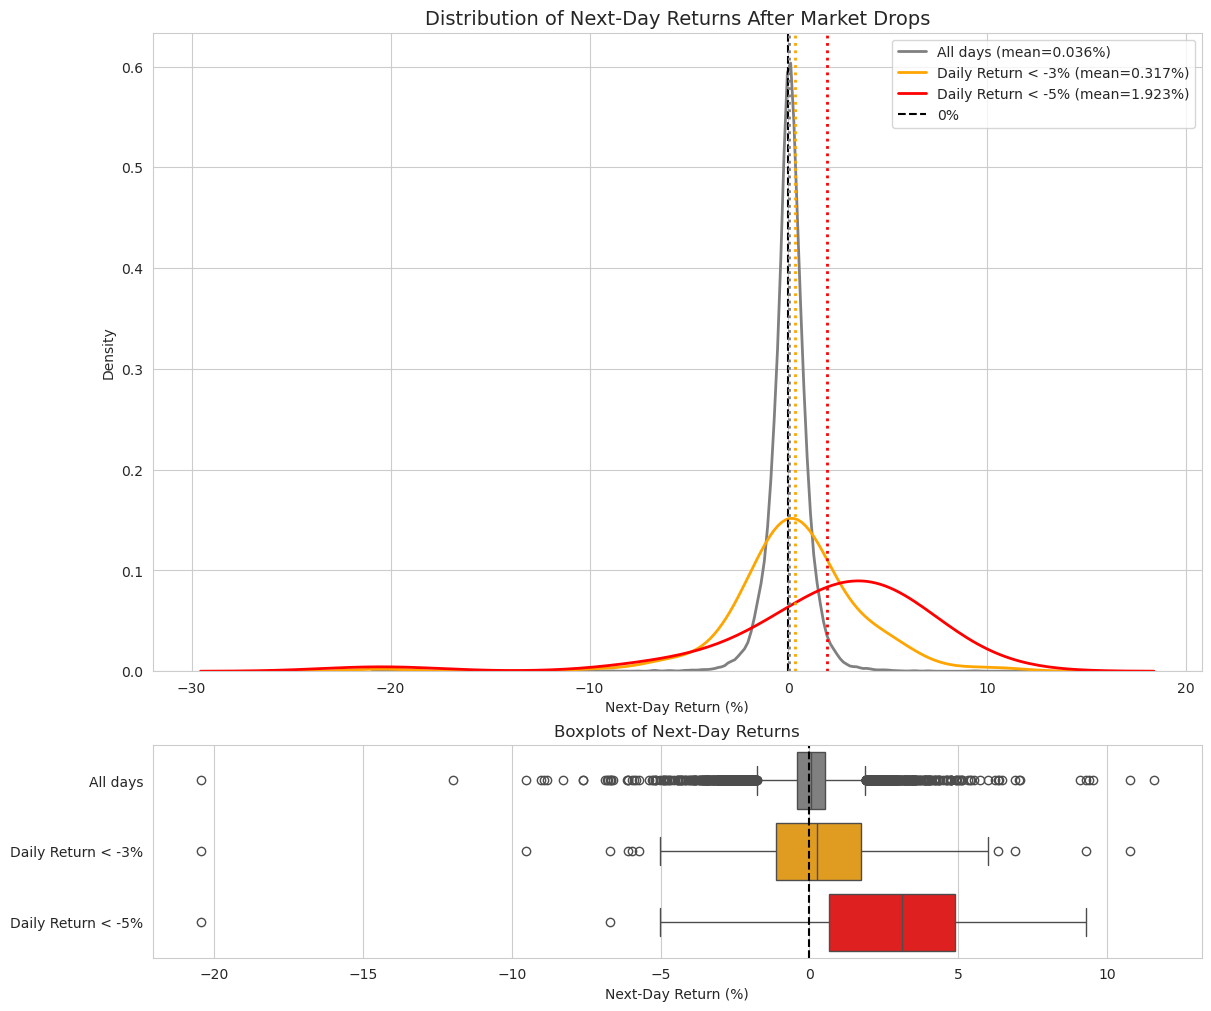

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plot_df = pd.concat([
    pd.DataFrame({
        "Group": "All days",
        "next_day_return": sp500["next_day_return"].dropna()
    }),
    pd.DataFrame({
        "Group": "Daily Return < -3%",
        "next_day_return": sp500.loc[sp500["crash_3"], "next_day_return"].dropna()
    }),
    pd.DataFrame({
        "Group": "Daily Return < -5%",
        "next_day_return": sp500.loc[sp500["crash_5"], "next_day_return"].dropna()
    }),
], ignore_index=True)

order = ["All days", "Daily Return < -3%", "Daily Return < -5%"]
palette = {
    "All days": "gray",
    "Daily Return < -3%": "orange",
    "Daily Return < -5%": "red",
}

means = (
    plot_df.groupby("Group")["next_day_return"]
    .mean()
    .reindex(order)
)

fig, axes = plt.subplots(
    2, 1, figsize=(12, 10),
    gridspec_kw={"height_ratios": [3, 1]},
    constrained_layout=True
)

# Overlaid KDEs
for group in order:
    sns.kdeplot(
        data=plot_df.loc[plot_df["Group"] == group],
        x="next_day_return",
        ax=axes[0],
        label=f"{group} (mean={means[group]:.3f}%)",
        color=palette[group],
        linewidth=2,
        fill=False,
        bw_adjust=1.1
    )

axes[0].axvline(0, color="black", linestyle="--", linewidth=1.5, label="0%")
for group in order:
    axes[0].axvline(
        means[group],
        color=palette[group],
        linestyle=":",
        linewidth=2
    )

axes[0].set_title("Distribution of Next-Day Returns After Market Drops", fontsize=14)
axes[0].set_xlabel("Next-Day Return (%)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Boxplots
sns.boxplot(
    data=plot_df,
    x="next_day_return",
    y="Group",
    order=order,
    palette=palette,
    ax=axes[1],
    orient="h"
)

axes[1].axvline(0, color="black", linestyle="--", linewidth=1.5)
axes[1].set_title("Boxplots of Next-Day Returns", fontsize=12)
axes[1].set_xlabel("Next-Day Return (%)")
axes[1].set_ylabel("")

plt.show()



If you want, the next step can be a **brief interpretation of the actual plotted shapes** (skew, tail behavior, and whether rebounds are concentrated in a few outliers).

**Deciding on analysis approach**

I need to choose between Path A or B for my analysis. The latest outputs give a chart figure and a numeric comparison table. The goal requires me to summarize skew and extreme rebounds that are affecting averages and dispersion comparisons. I have enough data from previous outputs to go with Path A.

I should analyze the latest outputs and connect the insights without restating the visible outputs directly. It’s all about concise interpretation. Let’s put that together!

<!--final answer-->
The plots support a clear pattern: **next-day returns shift upward after extreme down days, but they also become much more dispersed**.

- **All days** form the tightest distribution, centered close to zero with a slight positive tilt.
- After **daily drops worse than -3%**, the next-day distribution moves somewhat to the right, indicating a modest rebound tendency.
- After **daily drops worse than -5%**, the distribution shifts much more strongly to the right, consistent with a much larger average rebound.

On skewness:

- The crash-day groups appear **less symmetric and more irregular** than the full-sample distribution because they are based on far fewer observations and much higher volatility.
- For the **< -5%** group, the fact that the **median next-day return is well above zero and even above the mean** suggests the rebound effect is **not just coming from a couple of huge outliers**. The central tendency itself is strongly positive.
- For the **< -3%** group, the rebound is weaker and looks more mixed.

On whether extreme rebounds are driving the average:

- For **< -3%**, the mean is only modestly above the median, so large rebounds may help the average somewhat, but they do **not** appear to be the whole story.
- For **< -5%**, the boxplot and summary stats suggest **broadly positive post-crash behavior**, not merely a few exceptional bounce days.

On dispersion:

- Dispersion rises sharply as the prior-day drop gets more severe.
- The boxplots should show this clearly: the **< -3%** and especially **< -5%** groups have much wider spread and more extreme observations than the full sample.
- That matches the summary statistics, where next-day volatility after crash days is several times larger than normal.

So the main takeaway is:

- **Yes, there is evidence of mean reversion after extreme negative days**, especially after **very large drops below -5%**.
- But that rebound comes with **substantially higher uncertainty**, so the post-crash environment is not just more positive on average—it is also much more volatile.

Split the analysis of next-day returns after extreme down days into two periods:

* Pre-2000
* Post-2000

Tasks:

* Recompute mean, median, and win rate for next-day returns after:

  * Daily Return < -3%
  * Daily Return < -5%
* Compare results across the two periods

Check whether the mean reversion effect is stable or has changed over time.

The full-sample results showed mean reversion, especially for `Daily Return < -5%`, but that group only had **30** cases total, so the pre/post-2000 split may be a bit noisy.

A good next step is to compute the period-by-period summary table first:



In [7]:
import pandas as pd
from IPython.display import display

period_mask = sp500["Date"] < pd.Timestamp("2000-01-01")
sp500["Period"] = period_mask.map({True: "Pre-2000", False: "Post-2000"})

rows = []
for period in ["Pre-2000", "Post-2000"]:
    for label, mask in {
        "Daily Return < -3%": sp500["crash_3"],
        "Daily Return < -5%": sp500["crash_5"],
    }.items():
        s = sp500.loc[(sp500["Period"] == period) & mask, "next_day_return"].dropna()
        rows.append({
            "Period": period,
            "Group": label,
            "N": len(s),
            "Mean (%)": s.mean(),
            "Median (%)": s.median(),
            "Win Rate (%)": s.gt(0).mean() * 100,
        })

period_comparison = pd.DataFrame(rows).round(3)
display(period_comparison)

period_comparison

,Period,Group,N,Mean (%),Median (%),Win Rate (%)
0,Pre-2000,Daily Return < -3%,34,0.145,0.604,61.765
1,Pre-2000,Daily Return < -5%,10,0.653,2.591,80.000
2,Post-2000,Daily Return < -3%,98,0.377,0.238,56.122
3,Post-2000,Daily Return < -5%,20,2.559,3.651,75.000


,Period,Group,N,Mean (%),Median (%),Win Rate (%)
0,Pre-2000,Daily Return < -3%,34,0.145,0.604,61.765
1,Pre-2000,Daily Return < -5%,10,0.653,2.591,80.000
2,Post-2000,Daily Return < -3%,98,0.377,0.238,56.122
3,Post-2000,Daily Return < -5%,20,2.559,3.651,75.000


**Analyzing rebound trends**

I'm looking at rebound trends before and after 2000. In the pre-2000 period with a smaller mean but a higher median, it suggests more consistent, milder bounces. For rebounds of less than -5%, the pre-2000 mean is 0.653 and the median is 2.591, showing an 80% win rate. Post-2000, the mean is 2.559 and median at 3.651 with a 75% win rate. This indicates stronger post-2000 rebounds in magnitude, but the samples are quite small. I need to mention that sample sizes are important, especially for rebounds of less than -5%.

<!--final answer-->
The split suggests that **next-day mean reversion is present both before and after 2000**, but its **shape has changed**.

- After **drops worse than -3%**, both periods still show a positive next-day average, so the rebound effect did not disappear.
  - **Pre-2000** looks more **consistent**: higher median and higher win rate.
  - **Post-2000** has the **larger mean**, but a lower median and lower win rate. That points to rebounds that are **less frequent or less uniform**, with some bigger upside days lifting the average.

- After **drops worse than -5%**, the rebound effect appears **stronger post-2000**:
  - The **mean** is much higher post-2000.
  - The **median** is also higher post-2000, which is important because it suggests the stronger result is **not only** coming from a few extreme bounce days.
  - The **win rate** stays high in both periods, though it is slightly lower post-2000.

So the best overall reading is:

- **Mean reversion remains stable in direction** across both eras: extreme down days are followed, on average, by positive next-day returns both pre-2000 and post-2000.
- **Its magnitude has generally strengthened after 2000**, especially for the most severe down days.
- **Its consistency is more mixed after 2000**, particularly for the `< -3%` group, where the average rebound is stronger but the median/win rate are weaker.

One caution: the **`< -5%` sample is very small** in each split (`N=10` pre-2000, `N=20` post-2000), so that part of the comparison is directionally useful but should be treated as noisy.

add disclaimer that it is not financial advice

**Adding disclaimer for advice**

I need to make sure to include a disclaimer that this isn’t financial advice when answering the user's question. It's crucial to state that, without adding any code since I just need to modify text. I should mention the outputs clearly but keep it concise and natural, without headers. The currency rule isn't relevant here, so let's focus on crafting a brief summary that includes the necessary disclaimer.

Yes — here’s a clean version with the disclaimer included:

The period split shows that the **next-day mean reversion effect remains positive both before and after 2000**, but it looks **stronger post-2000**, especially after the most extreme down days.

- For **Daily Return < -3%**:
  - **Pre-2000:** mean `0.145%`, median `0.604%`, win rate `61.8%` (`N=34`)
  - **Post-2000:** mean `0.377%`, median `0.238%`, win rate `56.1%` (`N=98`)

  Interpretation: the rebound is still present in both periods. Post-2000 has a higher **average** bounce, but pre-2000 had a higher **median** and **win rate**, suggesting the earlier period may have had more consistent rebounds, while the later period may include a few larger upside reversals that lift the mean.

- For **Daily Return < -5%**:
  - **Pre-2000:** mean `0.653%`, median `2.591%`, win rate `80.0%` (`N=10`)
  - **Post-2000:** mean `2.559%`, median `3.651%`, win rate `75.0%` (`N=20`)

  Interpretation: the rebound effect appears materially stronger post-2000 for the most severe down days. Both the mean and median are higher, while the win rate stays high in both periods.

Overall, the evidence suggests:

- The **direction** of mean reversion is stable over time: extreme down days are followed by positive next-day returns on average in both eras.
- The **magnitude** appears to have increased after 2000, especially for very large selloffs.
- The **consistency** is less clearly improved, since medians and win rates do not uniformly rise.

One important caution: the `< -5%` group is based on a **small sample** (`10` pre-2000, `20` post-2000), so those estimates are more sensitive to a few unusual episodes.

**Disclaimer:** This analysis is for educational and research purposes only and **is not financial advice**. Past market behavior does not guarantee future results, and these patterns should not be used on their own as an investment strategy.